| # | Questions |
|---|---|
| 1 | Can an off-the-shelf sentiment tool read Steam reviews? VARD |
| 2 | Can a model trained on Steam's own labels do better? |
| 3 | What did that model actually learn? |
| 4 | When a review's text and its thumb disagree — who's right? |
| 5 | What are players actually complaining about, game by game? |



## 0. Setup

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

# Self-installing deps (same convention as notebook 02)
try:
    from sklearn.pipeline import make_pipeline
except ImportError:
    %pip install scikit-learn -q
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    %pip install vaderSentiment -q
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

DATA_PATH = 'data/reviews_prepared.csv'
FIG_DIR, MODEL_DIR = 'figures', 'models'
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(MODEL_DIR, exist_ok=True)
SEED = 42

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10})
C_POS, C_NEG, C_HI, C_MUT = '#2a9d8f', '#e76f51', '#e9c46a', '#9aa5b1'

def save(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}.png', bbox_inches='tight', dpi=150)
    print(f'saved figures/{name}.png')

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
nlp = df[df['use_nlp']].copy()
print(f"{len(nlp):,} NLP-eligible reviews of {len(df):,} total | {nlp['title_clean'].nunique()} games")
print(f"Class balance: {nlp['rec'].mean():.1%} positive — note this number, it matters below")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\jaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
14,477 NLP-eligible reviews of 14,617 total | 23 games
Class balance: 71.0% positive — note this number, it matters below


## Question 1 — Can an off-the-shelf sentiment tool read Steam reviews?

The cheapest possible solution is a pre-built sentiment library. VADER is the standard choice
for short social-media-style text and needs zero training. If it reads gamer language well,
this notebook can stop early. Score every review, call compound ≥ 0.05 "positive" (the
documented convention), and grade it against the reviewers' own thumbs:

In [3]:
an = SentimentIntensityAnalyzer()
nlp['vader_compound'] = nlp['review_text'].astype(str).map(lambda t: an.polarity_scores(t)['compound'])
nlp['vader_pred'] = (nlp['vader_compound'] >= 0.05).astype(int)

maj_acc = nlp['rec'].mean()
v_acc = accuracy_score(nlp['rec'], nlp['vader_pred'])
v_f1n = f1_score(nlp['rec'], nlp['vader_pred'], pos_label=0)
v_f1p = f1_score(nlp['rec'], nlp['vader_pred'])
print(f"Always-guess-positive: accuracy {maj_acc:.1%} | F1(neg) 0.00")
print(f"VADER:                 accuracy {v_acc:.1%} | F1(neg) {v_f1n:.2f} | F1(pos) {v_f1p:.2f}")
print()
cm = confusion_matrix(nlp['rec'], nlp['vader_pred'])
print("VADER confusion matrix [rows = actual neg/pos, cols = predicted neg/pos]:")
print(cm)
print(f"\nVADER calls {cm[0,1]:,} of {cm[0].sum():,} negative reviews 'positive' ({cm[0,1]/cm[0].sum():.0%} of all negatives missed)")

Always-guess-positive: accuracy 71.0% | F1(neg) 0.00
VADER:                 accuracy 71.9% | F1(neg) 0.55 | F1(pos) 0.79

VADER confusion matrix [rows = actual neg/pos, cols = predicted neg/pos]:
[[2533 1660]
 [2413 7871]]

VADER calls 1,660 of 4,193 negative reviews 'positive' (40% of all negatives missed)


**What we found.** VADER's accuracy (71.9%) is statistically indistinguishable from guessing
*Recommended* every time (71.0%) — and it waves through **40% of negative reviews** as positive.
Why so poor? Its lexicon was built for tweets, not gamers: a review like *"servers are dead,
got banned for nothing, refunded"* contains no classic negative-emotion words, while sarcastic
gamer idiom ("great, another crash") actively misleads it.


## Question 2 — Can a model trained on Steam's own labels do better?

The dataset's quiet superpower: every review is labelled *by its own author*. That means we can
train a classifier on Steam's actual language — `servers`, `refund`, `banned` — instead of
borrowed tweet vocabulary, and grade it honestly on held-out data.

Model choice is a scoping decision, made deliberately: **TF-IDF features + logistic
regression**. It trains in seconds, its decisions are fully inspectable (every prediction is a
sum of word weights we can print), and at ~14.5k short documents it is a known-strong baseline.
A fine-tuned transformer (e.g. DistilBERT) would likely buy a few F1 points at the cost of
opacity, GPU dependency and reviewer-side setup pain — the wrong trade for a system whose
architecture promises transparency wherever a decision is made. That upgrade path stays on the
production roadmap, not in this prototype.

Split 80/20 stratified, with bigrams so negation ("not bad", "not worth") is visible:

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    nlp['review_text'].astype(str), nlp['rec'],
    test_size=0.2, random_state=SEED, stratify=nlp['rec'])

pipe = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=30000,
                    sublinear_tf=True, strip_accents='unicode'),
    LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced'))

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

t_acc = accuracy_score(y_test, pred)
t_f1n = f1_score(y_test, pred, pos_label=0)
t_f1p = f1_score(y_test, pred)
print(f"TF-IDF + LogReg (held-out 20%): accuracy {t_acc:.1%} | F1(neg) {t_f1n:.2f} | F1(pos) {t_f1p:.2f}")
print("\nConfusion matrix [rows = actual neg/pos]:")
print(confusion_matrix(y_test, pred))

# Single splits can flatter — confirm with 5-fold cross-validation on the full subset
cv = cross_val_score(pipe, nlp['review_text'].astype(str), nlp['rec'],
                     cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring='f1_macro')
print(f"\n5-fold macro-F1: {np.round(cv, 3)}  (mean {cv.mean():.2f}) — stable across folds")

TF-IDF + LogReg (held-out 20%): accuracy 83.9% | F1(neg) 0.75 | F1(pos) 0.88

Confusion matrix [rows = actual neg/pos]:
[[ 682  157]
 [ 309 1748]]

5-fold macro-F1: [0.823 0.838 0.825 0.819 0.807]  (mean 0.82) — stable across folds


saved figures/06_model_comparison.png


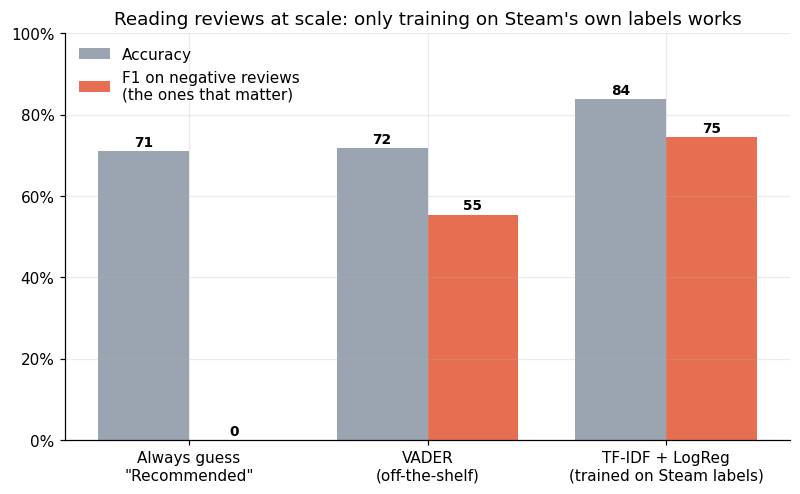

In [5]:
# The three-rung ladder in one picture
fig, ax = plt.subplots(figsize=(8.5, 4.8))
models = ['Always guess\n"Recommended"', 'VADER\n(off-the-shelf)', 'TF-IDF + LogReg\n(trained on Steam labels)']
accs = [maj_acc, v_acc, t_acc]
f1ns = [0.0, v_f1n, t_f1n]
x = np.arange(3); w = 0.38
b1 = ax.bar(x - w/2, [a*100 for a in accs], w, color=C_MUT, label='Accuracy')
b2 = ax.bar(x + w/2, [f*100 for f in f1ns], w, color=C_NEG, label='F1 on negative reviews\n(the ones that matter)')
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.2, f'{b.get_height():.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
ax.set_title('Reading reviews at scale: only training on Steam\'s own labels works')
ax.legend(loc='upper left', frameon=False)
save(fig, '06_model_comparison')
plt.show()

## Question 3 — What did the model actually learn?

A transparent model should be audited, not trusted. Logistic regression makes that trivial:
print the words with the largest learned weights in each direction. If the model learned
nonsense (game titles, artefacts), it shows up here immediately.

saved figures/07_model_vocabulary.png


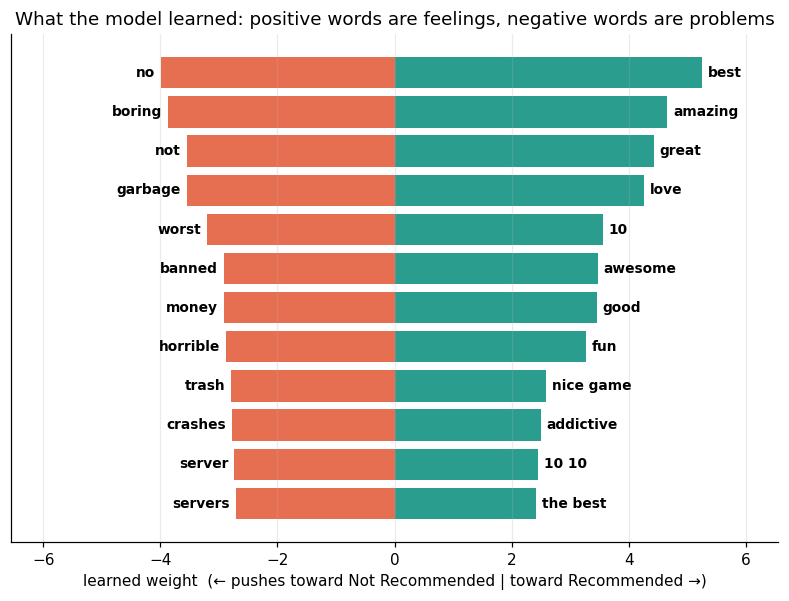

Strongest NEGATIVE indicators: no, boring, not, garbage, worst, banned, money, horrible, trash, crashes, server, servers
Strongest POSITIVE indicators: best, amazing, great, love, 10, awesome, good, fun, nice game, addictive, 10 10, the best


In [6]:
vec, clf = pipe.named_steps['tfidfvectorizer'], pipe.named_steps['logisticregression']
feats = np.array(vec.get_feature_names_out())
order = np.argsort(clf.coef_[0])
k = 12
top_neg, top_pos = feats[order[:k]], feats[order[-k:]][::-1]
w_neg, w_pos = clf.coef_[0][order[:k]], clf.coef_[0][order[-k:]][::-1]

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(k)
ax.barh(y, w_neg, color=C_NEG); ax.barh(y, w_pos, color=C_POS)
for i in range(k):
    ax.text(w_neg[i] - .1, i, top_neg[i], ha='right', va='center', fontsize=9, fontweight='bold')
    ax.text(w_pos[i] + .1, i, top_pos[i], ha='left', va='center', fontsize=9, fontweight='bold')
ax.set_yticks([]); ax.invert_yaxis()
lim = max(abs(w_neg.min()), w_pos.max()) * 1.25
ax.set_xlim(-lim, lim)
ax.set_xlabel('learned weight  (← pushes toward Not Recommended | toward Recommended →)')
ax.set_title('What the model learned: positive words are feelings, negative words are problems')
save(fig, '07_model_vocabulary')
plt.show()
print('Strongest NEGATIVE indicators:', ', '.join(top_neg))
print('Strongest POSITIVE indicators:', ', '.join(top_pos))

## Question 4 — When text and thumb disagree, who's right?

The model reads text; the thumb records a verdict. Usually they agree — where they don't,
something interesting is happening. To score every review fairly (no review judged by a model
that saw it in training), use 5-fold **out-of-fold** predictions, then pull the confident
disagreements in both directions:

In [7]:
oof = cross_val_predict(pipe, nlp['review_text'].astype(str), nlp['rec'],
                        cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                        method='predict_proba')[:, 1]
nlp['text_pos_proba'] = oof

down_but_positive = nlp[(nlp['rec'] == 0) & (nlp['text_pos_proba'] >= 0.80)]
up_but_negative   = nlp[(nlp['rec'] == 1) & (nlp['text_pos_proba'] <= 0.20)]
n_neg, n_pos = (nlp['rec'] == 0).sum(), (nlp['rec'] == 1).sum()
print(f"Thumb DOWN but text reads positive (p ≥ .80): {len(down_but_positive):>4} ({len(down_but_positive)/n_neg:.1%} of negatives)")
print(f"Thumb UP but text reads negative  (p ≤ .20): {len(up_but_negative):>4} ({len(up_but_negative)/n_pos:.1%} of positives)")

print("\nHow long are the disagreeing thumb-down reviews?")
print(down_but_positive['review_len_words'].describe().round(1)[['count','25%','50%','75%','max']].to_string())
print("\nThe shortest ones, verbatim:")
for _, r in down_but_positive.nsmallest(4, 'review_len_words').iterrows():
    print(f"  [{r['title_clean'][:24]}, thumbs-DOWN] {str(r['review_text'])!r}")

Thumb DOWN but text reads positive (p ≥ .80):   56 (1.3% of negatives)
Thumb UP but text reads negative  (p ≤ .20):  161 (1.6% of positives)

How long are the disagreeing thumb-down reviews?
count     56.0
25%        5.0
50%        8.0
75%       16.2
max      125.0

The shortest ones, verbatim:
  [Rocket League, thumbs-DOWN] 'fun'
  [Rocket League, thumbs-DOWN] 'good'
  [MONSTER HUNTER: WORLD, thumbs-DOWN] 'nice'
  [The Elder Scrolls V: Sky, thumbs-DOWN] 'loks like'


Half of these "disagreements" are under 8 words — *"good"*, *"fun"*, *"Awesome game"* — attached
to a thumbs-**down**. That's not the model misreading; that's **sarcasm and irony**, which no
bag-of-words can see and which would silently poison any text-only sentiment system (VADER
scores these confidently positive too). The thumb is the truth here.

The *substantive* disagreements (≥15 words) are a different species — and worth reading:

In [8]:
substantive = down_but_positive[down_but_positive['review_len_words'] >= 15]
print(f"Substantive disagreements (≥15 words): {len(substantive)}\n")
for _, r in substantive.sort_values('hour_played', ascending=False).head(4).iterrows():
    print(f"[{r['title_clean']}, {r['hour_played']:,}h played, text reads {r['text_pos_proba']:.0%} positive, thumb DOWN]")
    print(f"  {str(r['review_text'])[:260]!r}\n")

# Test the obvious hypothesis: are disagreeing negatives the most-invested players?
print(f"Median hours — disagreeing negatives: {down_but_positive['hour_played'].median():.0f}h "
      f"| all negatives: {nlp[nlp['rec']==0]['hour_played'].median():.0f}h")

# The actually-big devoted-critic population, measured directly:
deep_neg = nlp[(nlp['rec'] == 0) & (nlp['hour_played'] >= 100)]
print(f"\nNegative reviews from 100h+ players: {len(deep_neg):,} = {len(deep_neg)/n_neg:.0%} of ALL negative reviews")
print(f"Their median text positivity: {deep_neg['text_pos_proba'].median():.2f} — genuinely negative text, not hidden praise")

Substantive disagreements (≥15 words): 17

[Rust, 2,240h played, text reads 92% positive, thumb DOWN]
  'Its an amazing game the hyper realism is lovely. Still has a long way to go but even at this alpha stage its a great game. 10/10 would recommend.(bring back the bp system)!'

[Dead by Daylight, 1,647h played, text reads 85% positive, thumb DOWN]
  'Pretty good job so far. So expensive this game now microtransaction+dlc? omga skin is worth more than a dlc and almost than base game.....'

[PLAYERUNKNOWN'S BATTLEGROUNDS, 382h played, text reads 86% positive, thumb DOWN]
  "I love this game it is great fun but swarmed by cheaters and hackers. It's such a shame a good game is so ruined"

[Dead by Daylight, 225h played, text reads 91% positive, thumb DOWN]
  "Product received for free. best game i've ever seen before.love it but pairing system is suck and it dispoints me."

Median hours — disagreeing negatives: 66h | all negatives: 94h

Negative reviews from 100h+ players: 2,061 = 49% of 

**What we found.** Two honest results, one of which corrects our own hypothesis.

First, the substantive disagreements follow a single template: **"I love this game, BUT
\<dealbreaker\>"** — praise-heavy text where the thumb registers the one thing that broke it
(*cheaters*, *microtransactions*, *matchmaking*, *load times*). The model reads the praise; the
player votes the dealbreaker. For an acquirer these reviews are disproportionately valuable:
the dealbreaker is usually a *fixable, platform-relevant defect* attached to an otherwise loved
game.

Second, the "addicted but angry" hypothesis from our plan — that disagreement would expose
devoted players hiding love behind a protest thumb — is **not supported**: disagreeing
negatives have *fewer* hours than typical negatives (66h vs 94h median). The devoted critics
are real but hide nowhere: **49% of all negative reviews come from players with 100+ hours**,
and their text is genuinely negative. Negativity in this catalogue is mostly *informed*, which
is precisely why it deserves weight in the score rather than discounting.

## Question 5 — What are players actually complaining about, game by game?


In [9]:
STOP = set('''the a an and or but to of in is it i you for this game my that with not on was are
have be as so its at they if just dont can do all me more get when their your from will has had we
what about would there because been like even now out up no only games really very much who than
then some im ive isnt thats one play playing played still way time how after never go going make'''.split())

def tokens(s):
    return [w for w in re.findall(r"[a-z']{3,}", str(s).lower()) if w not in STOP]

neg_reviews, pos_reviews = nlp[nlp['rec'] == 0], nlp[nlp['rec'] == 1]
tc_neg, tc_pos = Counter(), Counter()
for t in neg_reviews['review_text']: tc_neg.update(tokens(t))
for t in pos_reviews['review_text']: tc_pos.update(tokens(t))
Tn, Tp = sum(tc_neg.values()), sum(tc_pos.values())

rows = []
for w in set(list(tc_neg) + list(tc_pos)):
    a, b = tc_neg[w], tc_pos[w]
    if a + b < 80:
        continue
    rows.append((w, a, b, np.log(((a+1)/Tn) / ((b+1)/Tp))))
tok_distinct = (pd.DataFrame(rows, columns=['word', 'neg_count', 'pos_count', 'log_odds'])
                  .sort_values('log_odds', ascending=False))
print("Most distinctively NEGATIVE words (by raw token counts):")
print(tok_distinct.head(20).round(2).to_string(index=False))

Most distinctively NEGATIVE words (by raw token counts):
      word  neg_count  pos_count  log_odds
  battleye        126          0      5.39
 corrupted        128          1      4.71
      data        130          6      3.47
       our        329         55      2.32
   garbage        118         22      2.19
     worst        154         34      2.03
     trash        111         27      1.93
unplayable         80         20      1.89
  horrible         96         25      1.86
    openiv         83         22      1.84
    banned        168         46      1.82
    refund        114         34      1.73
    broken        129         41      1.67
       ban         91         29      1.66
    ruined         69         22      1.65
  terrible        162         53      1.65
     waste        140         47      1.62
     worse        132         46      1.58
     sucks         92         36      1.46
      paid        112         44      1.46


In [10]:
for word in ['battleye', 'corrupted', 'mods']:
    contains = neg_reviews['review_text'].astype(str).str.contains(word, case=False)
    total = sum(str(t).lower().count(word) for t in neg_reviews['review_text'])
    print(f"'{word}': {total} occurrences — but in only {contains.sum()} distinct reviews")

# Show the spam itself: a window around the repeated word in the worst offender
culprits = neg_reviews[neg_reviews['review_text'].astype(str).str.lower().str.count('battleye') > 10]
text = str(culprits['review_text'].iloc[0]).lower()
i = text.find('battleye')
print(f"\nInside the worst offender ({culprits['title_clean'].iloc[0]}), verbatim window:")
print(repr(text[max(0, i-40): i+200]))

'battleye': 126 occurrences — but in only 2 distinct reviews
'corrupted': 128 occurrences — but in only 4 distinct reviews
'mods': 749 occurrences — but in only 310 distinct reviews

Inside the worst offender (PLAYERUNKNOWN'S BATTLEGROUNDS), verbatim window:
'battleye corrupted data battleye corrupted data battleye corrupted data battleye corrupted data battleye corrupted data battleye corrupted data battleye corrupted data battleye corrupted data battleye'


**A trap, caught.** `battleye` racks up 126 occurrences from **two** reviews that spam the word;
protest copy-pasta ("give our mods" pasted hundreds of times) does the same. Raw token counts
let one angry reviewer with a caps-lock key outvote a hundred measured ones. The fix is to count
**document frequency** — *what share of reviews mention a term at least once* — and to find
distinctive terms by comparing that share between negative and positive reviews (smoothed
log-odds):

In [11]:
nlp['tokset'] = nlp['review_text'].map(lambda s: set(tokens(s)))
neg_sets = nlp.loc[nlp['rec'] == 0, 'tokset']; pos_sets = nlp.loc[nlp['rec'] == 1, 'tokset']
cn, cp = Counter(), Counter()
for s in neg_sets: cn.update(s)
for s in pos_sets: cp.update(s)
Nn, Np = len(neg_sets), len(pos_sets)

rows = []
for w in set(list(cn) + list(cp)):
    a, b = cn[w], cp[w]
    if a + b < 60:
        continue
    rows.append((w, a, b, 100*a/Nn, 100*b/Np, np.log(((a+1)/Nn) / ((b+1)/Np))))
distinctive = (pd.DataFrame(rows, columns=['word', 'neg_reviews', 'pos_reviews', '%neg', '%pos', 'log_odds'])
                 .sort_values('log_odds', ascending=False))
print("Most distinctively NEGATIVE terms (by share of reviews mentioning them):")
print(distinctive.head(30).round(1).to_string(index=False))

Most distinctively NEGATIVE terms (by share of reviews mentioning them):
             word  neg_reviews  pos_reviews  %neg  %pos  log_odds
          garbage          109           20   2.6   0.2       2.6
            awful           55           11   1.3   0.1       2.4
             ping           52           11   1.2   0.1       2.4
            worst          142           32   3.4   0.3       2.4
            trash          104           24   2.5   0.2       2.3
       unplayable           78           18   1.9   0.2       2.3
           openiv           75           19   1.8   0.2       2.2
         horrible           89           23   2.1   0.2       2.2
           banned          141           38   3.4   0.4       2.2
           ruined           67           20   1.6   0.2       2.1
           refund          108           34   2.6   0.3       2.0
            worse          118           39   2.8   0.4       2.0
            waste          131           47   3.1   0.5       1.9
   

Now the list is clean — and the categories almost name themselves. Reading down it:
connectivity (`ping`, `laggy`, `servers`, `matchmaking`), stability (`unplayable`, `broken`,
`crashes`, `error`), enforcement (`banned`, `ban`, `cheaters`, `anti`[-cheat]), monetisation
(`microtransactions`, `crates`, `cash`, `paid`), and conduct aimed at the company rather than
the game (`openiv`, `company`, `support`, `refund`).

Curate those discovered terms into five named complaint themes and five praise themes
(positives, per Question 3, are vaguer — these lexicons are correspondingly broader). Every
keyword below either appears in the distinctive-terms table or is an obvious variant; the full
patterns are printed so the mapping is auditable:

In [12]:
COMPLAINT_THEMES = {
    'servers & connectivity': r'\bserver|ping\b|lag(?:gy|ging|s)?\b|matchmak|connect(?:ion|ing)?\b|disconnect|region',
    'bugs & stability':       r'\bbug(?:s|gy)?\b|crash|glitch|broken|unplayable|freez|error|fps\b|optimi[sz]|performance',
    'cheating & enforcement': r'cheat|hack(?:er|ers|ing)?\b|aimbot|\bban(?:ned|s)?\b|anti.?cheat|battleye|\bvac\b',
    'monetisation & price':   r'microtransaction|crates?\b|loot ?box|dlc|pay ?to ?win|p2w|cash|money|price|expensive|overpriced|shark card|greed|cash grab|money grab',
    'publisher conduct':      r'open ?iv|rockstar|take.?two|take2|bethesda|psyonix|creation club|paid mod|\bmod(?:s|ding|ders)?\b|publisher|\bcompany\b|\bdevs?\b|developer',
}
PRAISE_THEMES = {
    'fun & enjoyment':   r'\bfun\b|enjoy|blast\b|entertain',
    'friends & social':  r'friends?\b|co.?op|multiplayer|together|community',
    'depth & addiction': r'addict|hours? (?:of|in|and)|can.?t stop|hooked|replay',
    'story & world':     r'stor(?:y|ies)|world|atmosphere|character|immersi',
    'value for money':   r'worth|value|cheap|sale\b|free\b',
}

def theme_shares(frame, lexicon):
    text = frame['review_text'].astype(str)
    return pd.Series({k: text.str.contains(p, case=False, regex=True).mean() for k, p in lexicon.items()})

print("Share of ALL negative reviews mentioning each complaint theme:")
print((theme_shares(nlp[nlp['rec'] == 0], COMPLAINT_THEMES).sort_values(ascending=False) * 100).round(0).astype(int).astype(str).add('%').to_string())
any_pattern = '|'.join(COMPLAINT_THEMES.values())
coverage = nlp.loc[nlp['rec'] == 0, 'review_text'].astype(str).str.contains(any_pattern, case=False, regex=True).mean()
print(f"\nCoverage: {coverage:.0%} of negative reviews mention at least one theme")
print("\nShare of ALL positive reviews mentioning each praise theme:")
print((theme_shares(nlp[nlp['rec'] == 1], PRAISE_THEMES).sort_values(ascending=False) * 100).round(0).astype(int).astype(str).add('%').to_string())

Share of ALL negative reviews mentioning each complaint theme:
publisher conduct         26%
bugs & stability          22%
servers & connectivity    21%
monetisation & price      17%
cheating & enforcement    12%

Coverage: 62% of negative reviews mention at least one theme

Share of ALL positive reviews mentioning each praise theme:
fun & enjoyment      22%
friends & social     14%
value for money      13%
story & world         8%
depth & addiction     7%


saved figures/08_complaint_themes.png


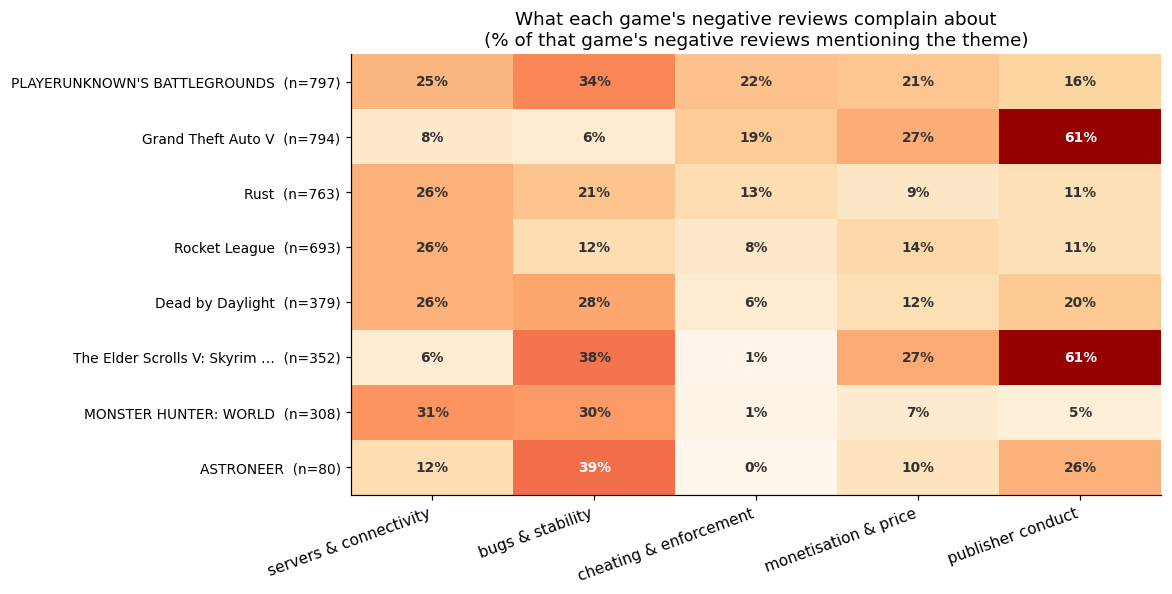

In [ ]:
# Per-game complaint profile — the heatmap the dashboard needs
MIN_NEG = 30
games = (nlp[nlp['rec'] == 0].groupby('title_clean').size()
           .loc[lambda s: s >= MIN_NEG].sort_values(ascending=False))
heat = pd.DataFrame({t: theme_shares(nlp[(nlp['rec'] == 0) & (nlp['title_clean'] == t)], COMPLAINT_THEMES)
                     for t in games.index}).T

fig, ax = plt.subplots(figsize=(9.5, 5.2))
im = ax.imshow(heat.values * 100, cmap='OrRd', aspect='auto', vmin=0, vmax=65)
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=20, ha='right')
labels = [f"{t if len(t) <= 30 else t[:28] + '…'}  (n={games[t]})" for t in heat.index]
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(labels, fontsize=9)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j] * 100
        ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=9,
                color='white' if v > 38 else '#333', fontweight='bold')
ax.set_title('What each game\'s negative reviews complain about\n(% of that game\'s negative reviews mentioning the theme)')
ax.grid(False)
save(fig, '08_complaint_themes')
plt.show()

**What we found.** Each game's complaint profile is distinct, and where we know the ground truth
the lexicons recover it independently: **GTA V's negatives are 61% publisher-conduct** (the
OpenIV protest from Step 2) and **Skyrim SE's are also 61% publisher-conduct** (the Creation
Club / paid-mods backlash) — the same two protests the Step 2 anomaly scan surfaced from a
completely different direction, which is exactly the kind of cross-method agreement that builds
trust in both. Meanwhile the profiles differentiate the rest: Monster Hunter's problem is
connectivity, ASTRONEER's is bugs, PUBG splits between stability and cheaters, Rocket League's
is servers.


## Every signal, saved

In [ ]:
# 1) Review-level scores (joins back to the prepared data by index)
review_scores = nlp[['title_clean', 'rec', 'text_pos_proba', 'vader_compound']].copy()
review_scores['disagree_down_but_positive'] = (nlp['rec'] == 0) & (nlp['text_pos_proba'] >= 0.80)
review_scores['disagree_up_but_negative']   = (nlp['rec'] == 1) & (nlp['text_pos_proba'] <= 0.20)
review_scores.to_csv('data/nlp_review_scores.csv', index_label='row_id')

# 2) Per-game signal table
def per_game(t):
    sub = nlp[nlp['title_clean'] == t]
    neg, pos = sub[sub['rec'] == 0], sub[sub['rec'] == 1]
    row = {'n_nlp': len(sub), 'n_neg': len(neg), 'n_pos': len(pos),
           'text_pos_mean': sub['text_pos_proba'].mean(),
           'disagree_rate': ((sub['rec'] == 0) & (sub['text_pos_proba'] >= .8)).mean()
                          + ((sub['rec'] == 1) & (sub['text_pos_proba'] <= .2)).mean()}
    for k in COMPLAINT_THEMES:
        row[f'complaint: {k}'] = theme_shares(neg, {k: COMPLAINT_THEMES[k]})[k] if len(neg) >= 20 else np.nan
    for k in PRAISE_THEMES:
        row[f'praise: {k}'] = theme_shares(pos, {k: PRAISE_THEMES[k]})[k] if len(pos) >= 20 else np.nan
    return pd.Series(row)

game_signals = pd.DataFrame({t: per_game(t) for t in sorted(nlp['title_clean'].unique())}).T
game_signals.index.name = 'title_clean'
game_signals.to_csv('data/nlp_game_signals.csv')
print('saved data/nlp_review_scores.csv  ', review_scores.shape)
print('saved data/nlp_game_signals.csv   ', game_signals.shape,
      '(theme shares NaN where n < 20 — too few reviews to trust a percentage)')
game_signals.round(2)

saved data/nlp_review_scores.csv   (14477, 6)
saved data/nlp_game_signals.csv    (23, 15) (theme shares NaN where n < 20 — too few reviews to trust a percentage)


,n_nlp,n_neg,n_pos,text_pos_mean,disagree_rate,complaint: servers & connectivity,complaint: bugs & stability,complaint: cheating & enforcement,complaint: monetisation & price,complaint: publisher conduct,praise: fun & enjoyment,praise: friends & social,praise: depth & addiction,praise: story & world,praise: value for money
title_clean,,,,,,,,,,,,,,,
ACE COMBAT 7: SKIES UNKNOWN,8.0,0.0,8.0,0.59,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASTRONEER,575.0,80.0,495.0,0.71,0.01,0.12,0.39,0.00,0.10,0.26,0.35,0.23,0.09,0.13,0.09
Beat Saber,10.0,0.0,10.0,0.66,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dead by Daylight,1025.0,379.0,646.0,0.57,0.01,0.26,0.28,0.06,0.12,0.20,0.29,0.21,0.08,0.05,0.14
Euro Truck Simulator 2,327.0,0.0,327.0,0.80,0.00,NaN,NaN,NaN,NaN,NaN,0.21,0.11,0.07,0.06,0.11
Factorio,157.0,0.0,157.0,0.70,0.01,NaN,NaN,NaN,NaN,NaN,0.18,0.15,0.18,0.06,0.10
Farming Simulator 19,7.0,4.0,3.0,0.47,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grand Theft Auto V,2146.0,794.0,1352.0,0.53,0.03,0.08,0.06,0.19,0.27,0.61,0.18,0.12,0.04,0.14,0.12
Insurgency: Sandstorm,206.0,12.0,194.0,0.71,0.00,NaN,NaN,NaN,NaN,NaN,0.26,0.11,0.04,0.06,0.04


In [ ]:
# 3) The trained pipeline, refit on ALL eligible data, for the dashboard's live use
try:
    import joblib
except ImportError:
    %pip install joblib -q
    import joblib
final_pipe = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=30000,
                    sublinear_tf=True, strip_accents='unicode'),
    LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced'))
final_pipe.fit(nlp['review_text'].astype(str), nlp['rec'])
joblib.dump(final_pipe, 'models/sentiment_pipeline.joblib')
print('saved models/sentiment_pipeline.joblib (held-out metrics above are the honest estimate of its quality)')

saved models/sentiment_pipeline.joblib (held-out metrics above are the honest estimate of its quality)


## Summary — what we found, and where it goes next

| # | Question we asked | Answer the data gave | Number to remember | Feeds into |
|---|---|---|---|---|
| 1 | Can an off-the-shelf tool read Steam? | No — VADER ≈ guessing the base rate | 71.9% vs 71.0%; misses 40% of negatives | justifies training our own |
| 2 | Can a trained model do better? | Yes, materially | 83.9% accuracy; F1(neg) 0.55 → 0.75; CV macro-F1 0.82 | review-level text sentiment for Step 4 |
| 3 | What did it learn? | Praise is feelings; complaints are *specifics* | top neg. weights: servers, banned, money, refund | motivates theme extraction |
| 4 | Text vs thumb — who's right? | Both: sarcasm fools text, "love it BUT" hides dealbreakers; devoted critics are openly negative | 49% of negatives come from 100h+ players | thumb + text both kept; disagreement queue for dashboard |
| 5 | What do players complain about? | Five themes, distinct per game; known protests recovered independently | GTA V & Skyrim SE: 61% publisher-conduct | theme profile per game; complaint-type weighting in Step 4 |
